In [1]:
import pandas as pd
import numpy as np

import tubesml as tml


import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

from source.report import report_points, report_victory, _point_to_proba


from sklearn.model_selection import KFold

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [2]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [3]:
df = pd.read_csv("data/processed/women_training.csv")

DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

df_train, df_test = tml.make_test(df, test_size=0.2, random_state=34)

In [17]:
result_dict["feat_imp"].head(20)

,Feature,shap_importance,shap_std,mean,std
0,delta_Seed,0.650582,0.009883,84.2,11.041965
1,delta_quality,0.485750,0.002539,35.8,3.664014
2,delta_FGM2,0.131202,0.001243,21.4,3.213254
3,delta_off_rating,0.081074,0.001139,19.0,4.123106
4,delta_FGM_perc,0.075778,0.001092,21.0,2.738613
5,delta_True_shooting_perc_diff,0.065676,0.000821,20.0,4.472136
6,delta_N_wins,0.061033,0.000809,19.8,3.990614
7,delta_Blk_diff,0.060823,0.001037,29.0,4.123106
8,delta_Ast_TO_ratio,0.051849,0.001013,23.2,4.865696
9,delta_OR_opportunity,0.048398,0.000553,20.4,3.581201


OOF score: 0.14519227036330337
[34, 50, 66, 90, 51]


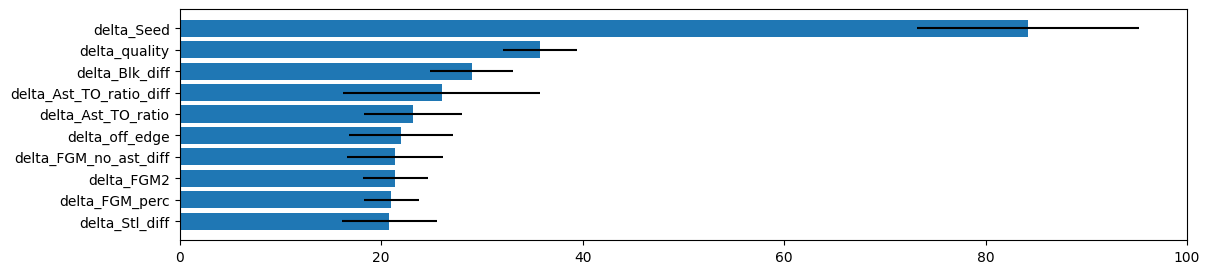

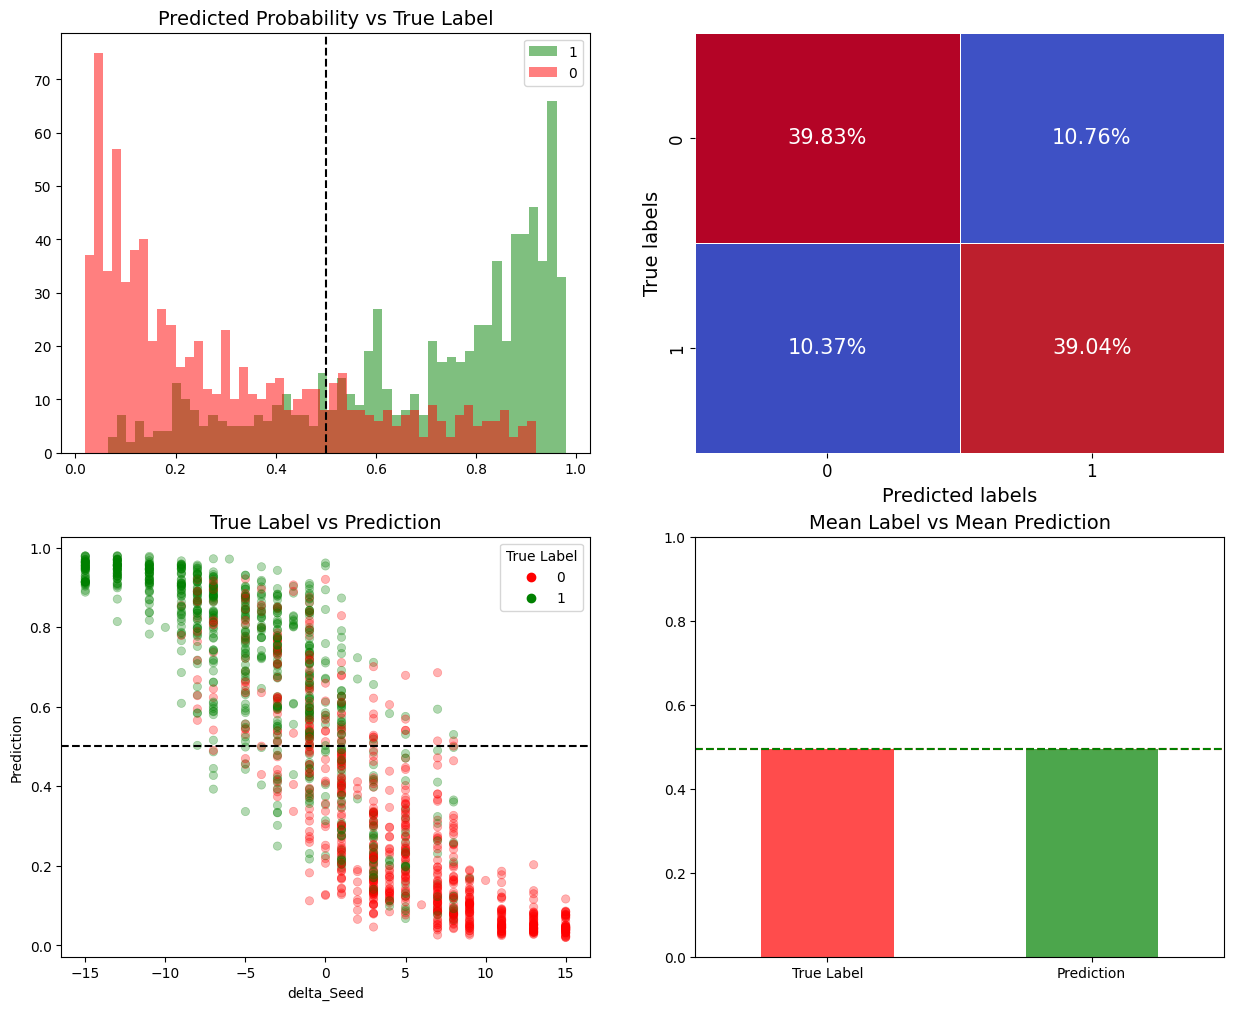

Accuracy score: 	0.7887
AUC ROC: 		0.8741
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       771
           1       0.78      0.79      0.79       753

    accuracy                           0.79      1524
   macro avg       0.79      0.79      0.79      1524
weighted avg       0.79      0.79      0.79      1524

Test score: 0.14160650422607698


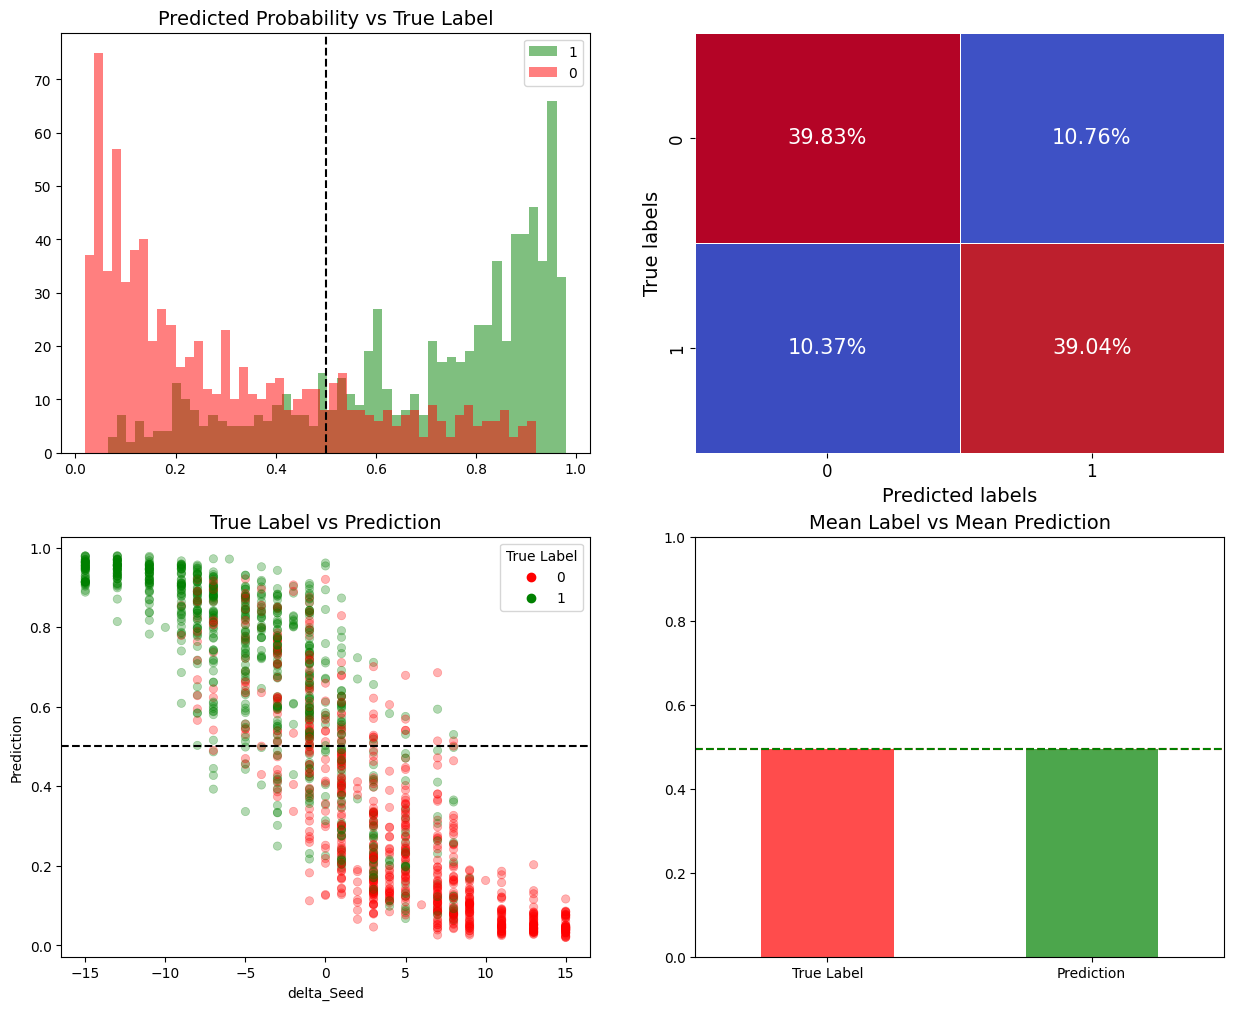

Accuracy score: 	0.7887
AUC ROC: 		0.8741
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       771
           1       0.78      0.79      0.79       753

    accuracy                           0.79      1524
   macro avg       0.79      0.79      0.79      1524
weighted avg       0.79      0.79      0.79      1524

Accuracy train: 		 0.7887
Accuracy test: 			 0.7906
Logloss train: 			 0.4443
Logloss test: 			 0.4377
Brier train: 			 0.1452
Brier test: 			 0.1416
Unsure train: 			 15.5512%
Unsure test: 			 15.9686%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.7887,0.7906,0.4443,0.4377,15.5512,15.9686,0.1452,0.1416


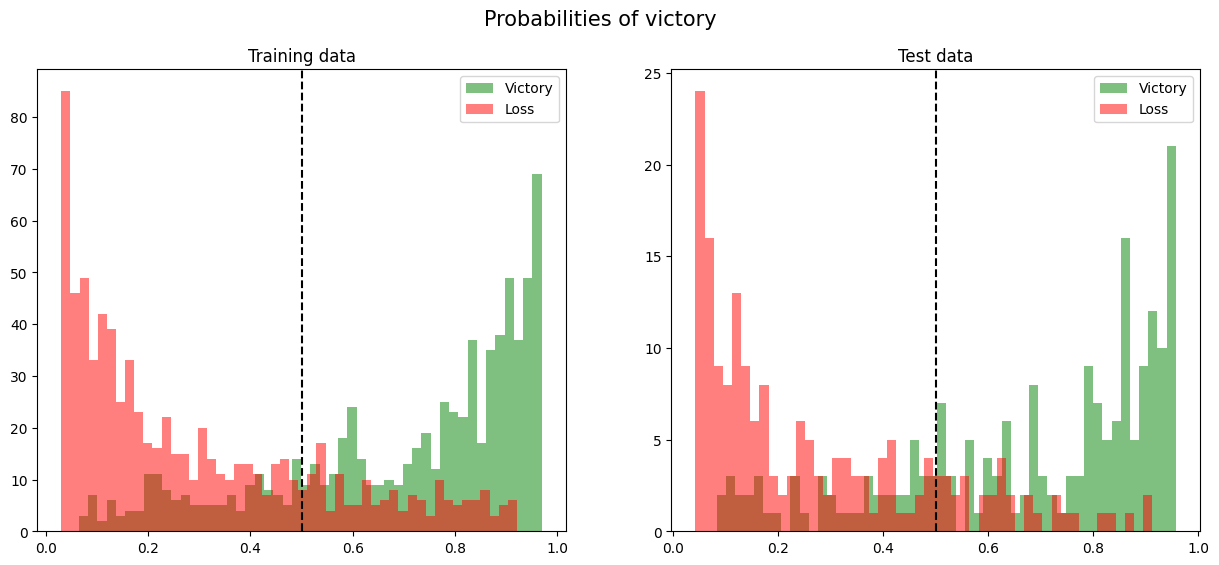

In [26]:
target = df_train["target"]

not_imp = [
    'delta_Score',
 'delta_opp_FGM3',
 'delta_def_rating',
 'delta_opp_PF',
 'delta_TO_diff',
 'delta_opp_possessions',
 'delta_FGA2',
 'delta_True_shooting_perc',
 'delta_DR_diff',
 'delta_Eff_FG_perc_diff',
 'delta_TO_perposs',
 'delta_FGM2_perc',
 'delta_TO_perposs_diff',
 'delta_PF_diff',
 'delta_FGM3',
 'delta_FG3_ratio_diff',
 'delta_FTA',
 'delta_OR',
 'delta_FG3_ratio',
 'delta_possessions'
    ]

extras = [#"T1_Opp_True_shooting_perc", "T2_Opp_True_shooting_perc",
          "T1_Seed", "T2_Seed",
          #"T1_impact", "T2_impact", "T1_FGM3_perc", "T2_FGM3_perc"
          ]
FEATURES = [c for c in df_train if "delta" in c and c not in DROP and c not in not_imp] #+ extras
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

model = lgb.LGBMClassifier(random_state=34, n_jobs=-1, verbose=-1, n_estimators=10000,
                               learning_rate=0.1,
                             colsample_bytree=0.817,
                             min_child_weight=5.62,
                             reg_lambda=14.72,
                             reg_alpha=2.16,
                             subsample=0.722,
                             num_leaves=66,
                             max_depth=95,
                             eval_metric="auc")

pipe = Pipeline([
                ("imp", tml.DfImputer()),
                ("model", model)])

callbacks = [lgb.early_stopping(1000, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "auc"}

oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=False, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

Accuracy train: 		 0.7887
Accuracy test: 			 0.7906
Logloss train: 			 0.4443
Logloss test: 			 0.4377
Brier train: 			 0.1452
Brier test: 			 0.1416
Unsure train: 			 15.5512%
Unsure test: 			 15.9686%

In [27]:
df_train["oof_prob"] = oof
df_test["pred_prob"] = pred

df_train["sqr_err_prob"] = (df_train["target"] - df_train["oof_prob"])**2
df_test["sqr_err_prob"] = (df_test["target"] - df_test["pred_prob"])**2

In [28]:
df_train.groupby("stage_Round1")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round1,
False,0.168253
True,0.122552


In [29]:
df_train.groupby("stage_Round2")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round2,
False,0.138808
True,0.163820


In [30]:
df_train.groupby("stage_Round3")[[ "sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round3,
False,0.141687
True,0.169224


In [31]:
df_train.groupby("stage_Round4")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_Round4,
False,0.144727
True,0.152697


In [32]:
df_train.groupby("stage_finalfour")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_finalfour,
False,0.142343
True,0.243334


In [33]:
df_train.groupby("stage_final")[["sqr_err_prob"]].mean()

,sqr_err_prob
stage_final,
False,0.145705
True,0.116763


In [32]:
thrs = np.arange(0, 25)

for th in thrs:
    tmp = df_train.copy()
    tmp.loc[(tmp["oof_prob"] > 0.5) & (tmp["oof_prob"] < 0.5 + th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 + th / 100
    tmp.loc[(tmp["oof_prob"] < 0.5) & (tmp["oof_prob"] > 0.5 - th / 100) & (tmp["stage_Round3"]), "oof_prob"] = 0.5 - th / 100
    tmp["sqr_err_prob"] = (tmp["target"] - tmp["oof_prob"])**2

    print(th, tmp["sqr_err_prob"].mean())

0 0.18855573120782013
1 0.18855546218282734
2 0.18855511587595866
3 0.18854683741394798
4 0.18854326475919975
5 0.18854318109008844
6 0.18854472172201672
7 0.1885583758814936
8 0.18856972992239843
9 0.18857969633999766
10 0.18859217652863292
11 0.18861264173457698
12 0.1886550072282353
13 0.18872546701048554
14 0.1888098015289669
15 0.1889061092009184
16 0.18902618777808125
17 0.18915948704913618
18 0.18931344486341317
19 0.18947606757847105
20 0.18964607916487072
21 0.1898333901616176
22 0.1900340726320296
23 0.1902522888234961
24 0.1904877208657307


Round 2 12
 

In [34]:
df_train.to_csv("data/results/women_train_lgb_class.csv", index=False)
df_test.to_csv("data/results/women_test_lgb_class.csv", index=False)